In [12]:
# -*- coding: utf-8 -*- 
# Schrodinger generator   last updated by by kjsun 01/28/2026
import numpy as np
import torch
import sys
#import torch.optim as optim
import matplotlib.pyplot as plt
#from torch.utils.data import TensorDataset, DataLoader
#import torch.nn as nn
#from torch.distributions import Distribution
#import math
#from scipy.stats import gaussian_kde
#from mpl_toolkits.mplot3d import Axes3D  # 必须导入 
import copy
from argparse import ArgumentParser
import logging
from srcSG_utilities import device_info, check_device_and_seed, _to_tensor 

from srcSG_integrand import CustomDistribution
from srcSG_integrand import fun_ws as fun_integrand
from srcSG_plot import plot_ais,plot_training_data_2d,plot_SG,plot_SG2,plot_SG_full,plot_correlation_function_mixed_event_fast,plot_correlation_function_mixed_event_fast_in_chunks
from srcSG_AIS import SG_AIS_integrator,SG_AIS_sampler,SG_AIS_resampler,SG_AIS_inverse_mapping,SG_AIS_mapping
from srcSG_Flow import prepare_nf_training_data,create_flow_from_args,SG_sampler,train_flow,CombinedFlow,SG_Ana,update_flow_boundaries,eval_flow_in_chunks, SG_Ana_nucleus, SG_sampler_nucleus 
 
device = device_info()
seed = 12345
check_device_and_seed(device, seed)
torch.set_default_dtype(torch.float64)
dtype = torch.get_default_dtype()
# ============================================================
# 0. Set AIS parameters
# ============================================================
Nd = 9
if Nd==2:
    from srcSG_integrand import fun_2D as fun_integrand
    scl=1.0
    gdv = [150 + k for k in range(Nd)]   # adjusted for GPU run
    Nsample = 200000
    Nstep = 20
    xmin=-6.0
    xmax=6.0
    batch_size = 5000
    
    
elif Nd==3:
    from srcSG_integrand import fden_3D_exact as fun_integrand
    scl=1.0
    gdv = [150 + k for k in range(Nd)]   # adjusted for GPU run
    Nsample = 200000
    Nstep = 20
    xmin=-6.0
    xmax=6.0
    batch_size = 50000    

elif Nd == 6:
    from srcSG_integrand import fun_cluster as fun_integrand
    scl=5.0    # very important
    gdv = [150 + k for k in range(Nd)]   # adjusted for GPU run
    Nsample = 200000
    Nstep = 20
    xmin=-6.0
    xmax=6.0
    batch_size = 50000

elif Nd == 9:
    from srcSG_integrand import fun_cluster as fun_integrand
    scl=5.0    # very important
    gdv = [150 + k for k in range(Nd)]   # adjusted for GPU run
    Nsample = 1000000
    Nstep = 20
    xmin=-6.0
    xmax=6.0
    batch_size = 50000

elif Nd == 12:
    from srcSG_integrand import fun_cluster as fun_integrand
    scl=4.0    # very important
    gdv = [150 + k for k in range(Nd)]   # adjusted for GPU run
    Nsample = 2000000
    Nstep = 20
    xmin=-6.0
    xmax=6.0
    batch_size = 50000

elif Nd == 18:
    from srcSG_integrand import fun_cluster as fun_integrand
    scl=5.0    # very important
    gdv = [150+100 + k for k in range(Nd)]   # adjusted for GPU run
    Nsample = 20000000
    Nstep = 150
    xmin=-5.0
    xmax=5.0
    batch_size = 200000
    
    

elif Nd == 24:
    from srcSG_integrand import fun_cluster as fun_integrand
    scl=2.0    # very important
    gdv = [150+100 + k for k in range(Nd)]   # adjusted for GPU run
    Nsample = 50000000
    Nstep = 20
    xmin=-5.0
    xmax=5.0
    batch_size = 500000

elif Nd == 36:
    from srcSG_integrand import fun_cluster as fun_integrand
    scl=2.0    # very important
    gdv = [150+100 + k for k in range(Nd)]   # adjusted for GPU run
    Nsample = 80000000
    Nstep = 100
    xmin=-5.0
    xmax=5.0
    batch_size = 500000

elif Nd == 60:
    from srcSG_integrand import fun_cluster as fun_integrand
    scl=2.0    # very important
    gdv = [150+100 + k for k in range(Nd)]   # adjusted for GPU run
    Nsample = 80000000
    Nstep = 100
    xmin=-5.0
    xmax=5.0
    batch_size = 500000



 

 
Iscal = scl**Nd   # scale factor  
b = 1.0
Rm = 2.3
R = 2.8

param_ais = {
    'nd': Nd, 
    'xmin': np.full(Nd, xmin),
    'xmax': np.full(Nd, xmax),
    'b': b,
    'Rm': Rm,
    'R': R,
    'scale':scl, 
    'Ra': 1.0,
    'Rb': -1.0,
    'b1': 2.0,
    'b2': 2.0,    
}

param_ais_resample = param_ais.copy() # For resampling 


# ============================================================
# 0. Set Flow parameters
# ============================================================
Nit = 151
# ----------------------------
# argparse + main entry (keeps your original CLI)
# ----------------------------
#import logging 
parser = ArgumentParser()
parser.add_argument("--batch", default=512, type=int)
parser.add_argument("--flows", default=4, type=int)
parser.add_argument("--num-bins", dest="num_bins", default=8, type=int)
parser.add_argument("--hidden-dim", dest="hidden_dim", default=256, type=int)
parser.add_argument("--iterations", default=Nit, type=int)
parser.add_argument("--use-mixture", action="store_true", default=True) 
#parser.add_argument("--use-mixture", action="store_true", default=False)
parser.add_argument("--convolve", action="store_true")
parser.add_argument("--actnorm", action="store_true")
#args = parser.parse_args()
args, unknown = parser.parse_known_args()
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

cluster_params = param_ais.copy()  # your earlier param dictionary 
#cluster_params['nd']=Nd*M
#cluster_params['xmin'] = np.full(Nd*M, xmin)
#cluster_params['xmax'] = np.full(Nd*M, xmax)



a = _to_tensor(param_ais['xmin'], dtype=dtype, device=device) 
b = _to_tensor(param_ais['xmax'], dtype=dtype, device=device) 
    
vol = torch.prod(b - a)


# ============================================================
# 1. Run AIS
# ============================================================
print(f"Running on device: {device}, dtype: {torch.get_default_dtype()}")
I, Ierr, I_MC, grid_ais = SG_AIS_integrator(fun_integrand, Nd, gdv, Nsample, Nstep, param_ais,
                                        device=device, batch_size=batch_size, seed=seed, stratified=False)

print(f"\nFinal result: {I.item()/Iscal} ± {Ierr.item()/Iscal}")

# Final sampling for visualization
Ns = 500000
x_ais, Jacobi, fw = SG_AIS_sampler(Ns, gdv, grid_ais, Nd, param_ais, fun_integrand,
                                  device=device, batch_size=10000, stratified=False)
x0 = SG_AIS_inverse_mapping(x_ais, param_ais,Nd,gdv,grid_ais)
x_ais_resample=[]

for k in range(2):
    print(k)
    x_ais_resample_, status = SG_AIS_resampler(gdv, grid_ais, fun_integrand, param_ais_resample,device=device,total_proposals=10000000,n_final=Ns,batch_proposal=20000)
    x_ais_resample.append(x_ais_resample_)

x_ais_resample = torch.cat(x_ais_resample,dim=0)

x0_resample = SG_AIS_inverse_mapping(x_ais_resample, param_ais,Nd,gdv,grid_ais)
if device.type=='cpu':
    plot_ais(x0,x_ais*0.5,x0_resample,x_ais_resample*0.5) 
    plot_correlation_function_mixed_event_fast_in_chunks(x_ais,1000,1000000,device=device) 
    plot_correlation_function_mixed_event_fast_in_chunks(x_ais_resample,1000,10000,device=device)

Running on device: cuda, dtype: torch.float64
01  I = 2.42639287e+06  +/- 3.17e+05   chi2/dof ~ 0.000
02  I = 1.85255324e+06  +/- 5.53e+04   chi2/dof ~ 1.687
03  I = 1.91863671e+06  +/- 2.29e+04   chi2/dof ~ 1.699
04  I = 1.94805286e+06  +/- 1.35e+04   chi2/dof ~ 1.910
05  I = 1.94993626e+06  +/- 9.93e+03   chi2/dof ~ 1.536
06  I = 1.95145960e+06  +/- 8.17e+03   chi2/dof ~ 1.292
07  I = 1.95740175e+06  +/- 7.09e+03   chi2/dof ~ 1.415
08  I = 1.95709606e+06  +/- 6.34e+03   chi2/dof ~ 1.239
09  I = 1.95799226e+06  +/- 5.79e+03   chi2/dof ~ 1.115
10  I = 1.95855498e+06  +/- 5.36e+03   chi2/dof ~ 1.010
11  I = 1.95776283e+06  +/- 7.07e+03   chi2/dof ~ 0.113
12  I = 1.95947682e+06  +/- 6.33e+03   chi2/dof ~ 0.150
13  I = 1.96013029e+06  +/- 5.78e+03   chi2/dof ~ 0.136
14  I = 1.96117332e+06  +/- 5.36e+03   chi2/dof ~ 0.149
15  I = 1.95754429e+06  +/- 5.00e+03   chi2/dof ~ 0.580
16  I = 1.95827923e+06  +/- 4.72e+03   chi2/dof ~ 0.537
17  I = 1.95681432e+06  +/- 4.47e+03   chi2/dof ~ 0.578
18

In [13]:
 
print(torch.__version__)

2.3.0+cu121


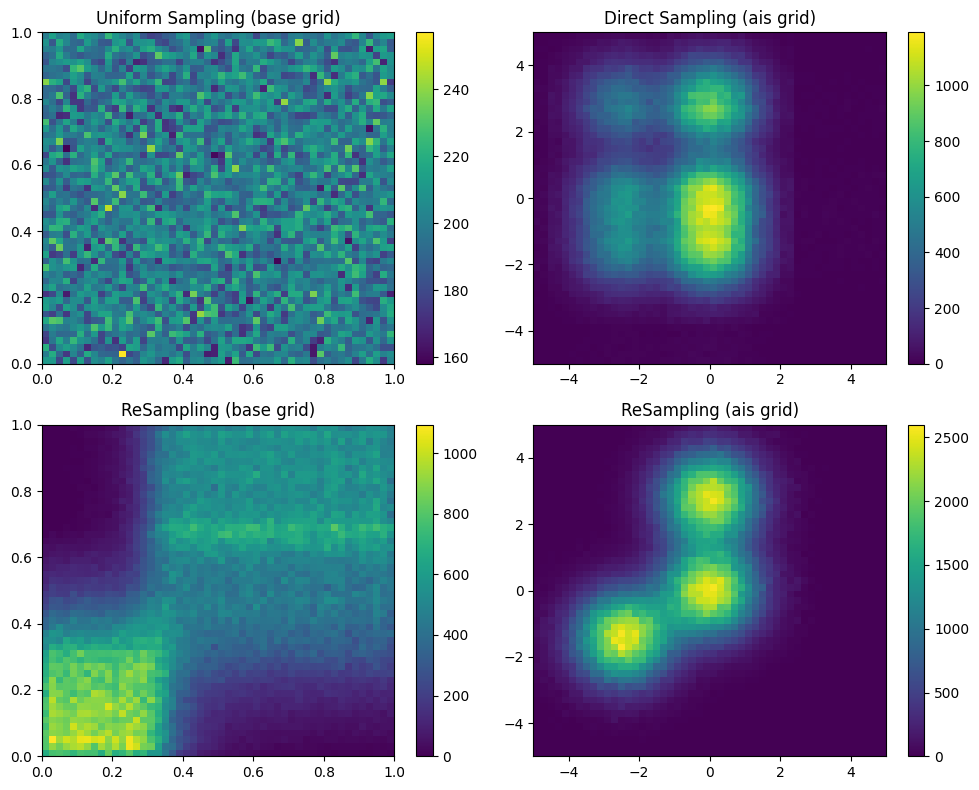

In [14]:
plot_ais(x0,x_ais,x0_resample,x_ais_resample)

In [15]:
# Schrodinger generator-flow phase   
Nit=100
# training dataset
if Nd == 12:
    Ns = 100000
    batch_size = 20000
    Nit = 200
    lr_max=1e-4
    B=2.5
    x_max =2.5
    dirsave = 'results_SG_cluster'

elif Nd == 18:
    Ns = 200000
    batch_size = 50000
    Nit = 2000
    lr_max=1e-4
    B=2.0
    x_max =2.0
    dirsave = 'results_SG_cluster'
elif Nd == 24:
    Ns = 1000000
    batch_size = 100000
    Nit = 200
    lr_max=1e-5
    B=5.0
    x_max =4.0
    dirsave = 'results_SG_cluster'
elif Nd == 9:
    Ns = 60000
    batch_size = 20000
    Nit=200
    lr_max=2e-4
    B=3.0
    x_max =3.0
    dirsave = 'results_SG_cluster'
elif Nd == 6:
    Ns = 60000
    batch_size = 20000
    Nit=200
    lr_max=5e-4
    B=3.0
    x_max =3.0
    dirsave = 'results_SG_cluster'
elif Nd == 2:
    Ns = 40000
    batch_size = 10000
    Nit=200
    lr_max=1e-3  #5e-4
    B=3.5
    x_max =3.5
    dirsave = 'results_SG_cluster'
    
elif Nd == 3:
    Ns = 40000
    batch_size = 10000
    Nit=200
    lr_max=1e-3  #5e-4
    B=3.5
    x_max =3.5
    dirsave = 'results_SG_cluster'    

x_train, J_vg, f_vg = SG_AIS_sampler(Ns, gdv, grid_ais, Nd,param_ais, fun_integrand,
                                  device=device, batch_size=batch_size, stratified=False)
train_loader, train_dataset = prepare_nf_training_data(x_train, batch_size=batch_size)
if device=='cpu':
    plot_training_data_2d(train_dataset, dim1=0, dim2=1, bins=100, scatter=True, hist2d=True)

    
modelA = create_flow_from_args(args=args, dim=Nd, cluster_params=cluster_params,funA=fun_integrand, device=device,fun=CustomDistribution,B=B,x_max=x_max)
model0 = copy.deepcopy(modelA).to(device)
trained_modelA, loss_hist = train_flow(model=modelA, train_loader=train_loader, Nd=Nd, epochs=args.iterations, lr_max=lr_max,device=device,dirsave=dirsave)

if device=='cpu':
    plt.figure(figsize=(10, 8))
    plt.plot(loss_hist)
    plt.title('Loss_{flow}')
    plt.show()
x_ais=x_ais.to(device)
x_train=x_train.to(device)
with torch.no_grad():
    x_ais_nf0,_,_ = model0(x_ais)
    x_ais_nf,_,_ = trained_modelA(x_ais)
    x_train_B,_,_ = trained_modelA(x_train)

if device=='cpu':
    plot_SG(x0,x_ais,x0_resample,x_ais_resample,x_ais_nf0)
    plot_SG(x0,x_ais,x0_resample,x_ais_resample,x_ais_nf)
    

Epoch 1/151 AvgLoss=12.8604 Best=12.8604
Epoch 11/151 AvgLoss=8.9095 Best=8.9095
Epoch 21/151 AvgLoss=7.7283 Best=7.7283
Epoch 31/151 AvgLoss=7.1887 Best=7.1887
Epoch 41/151 AvgLoss=6.9074 Best=6.9074
Epoch 51/151 AvgLoss=6.7819 Best=6.7728
Epoch 61/151 AvgLoss=6.6564 Best=6.6564
Epoch 71/151 AvgLoss=6.6568 Best=6.6235
Epoch 81/151 AvgLoss=6.5522 Best=6.5522
Epoch 91/151 AvgLoss=6.4781 Best=6.4781
Epoch 101/151 AvgLoss=6.4515 Best=6.4515
Epoch 111/151 AvgLoss=6.4237 Best=6.4237
Epoch 121/151 AvgLoss=6.4026 Best=6.4026
Epoch 131/151 AvgLoss=6.3900 Best=6.3900
Epoch 141/151 AvgLoss=6.3794 Best=6.3794
Epoch 151/151 AvgLoss=6.3774 Best=6.3774


In [16]:
if Nd == 12:
    Ns = 100000
    batch_size = 20000
    Nit = 100
    lr_max=1e-4
    B=6.0
    x_max =4.0
    dirsave = 'results_SG_cluster'

elif Nd == 18:
    Ns = 200000
    batch_size = 50000
    Nit = 1000
    lr_max=1e-4
    B=5.0
    x_max =4.0
    dirsave = 'results_SG_cluster'
elif Nd == 24:
    Ns = 1000000
    batch_size = 100000
    Nit = 200
    lr_max=1e-4
    B=5.5
    x_max =5.0
    dirsave = 'results_SG_cluster'
elif Nd == 9:
    Ns = 60000
    batch_size = 20000
    Nit=100
    lr_max=2e-4
    B=6.0
    x_max =4.0
    dirsave = 'results_SG_cluster'
elif Nd == 6:
    Ns = 40000
    batch_size = 20000
    Nit=100
    lr_max=2e-4
    B=6.0
    x_max =4.0
    dirsave = 'results_SG_cluster'
elif Nd == 2:
    Ns = 40000
    batch_size = 10000
    Nit=200
    lr_max=1e-4  #5e-4
    B=6.0
    x_max =4.0
    dirsave = 'results_SG_cluster'
    
elif Nd == 3:
    Ns = 40000
    batch_size = 10000
    Nit=200
    lr_max=1e-4  #5e-4
    B=6.0
    x_max =4.0
    dirsave = 'results_SG_cluster'    

    
modelB = create_flow_from_args(args=args, dim=Nd, cluster_params=cluster_params,funA=fun_integrand, device=device,fun=CustomDistribution,B=B,x_max=x_max)
model1 = copy.deepcopy(modelB).to(device)
train_loader_B, train_dataset_B = prepare_nf_training_data(x_train_B, batch_size=batch_size)
if device=='cpu':
    plot_training_data_2d(train_dataset_B, dim1=0, dim2=1, bins=100, scatter=True, hist2d=True)

trained_modelB, loss_hist_B = train_flow(model=modelB, train_loader=train_loader_B, Nd=Nd, epochs=args.iterations, lr_max=lr_max,device=device,dirsave=dirsave)

x_ais_nf=x_ais_nf.to(device)
with torch.no_grad():
    x_ais_nf2,_,_ = model1(x_ais_nf)
    x_ais_nfB,_,_ = trained_modelB(x_ais_nf)
    x_train_C,_,_ = trained_modelB(x_train_B)
if device=='cpu':
    plot_SG(x0,x_ais,x0_resample,x_ais_resample,x_ais_nf2)
    plot_SG(x0,x_ais,x0_resample,x_ais_resample,x_ais_nfB)

loss = []
loss.append(loss_hist)
loss.append(loss_hist_B)
if device=='cpu':
    plt.figure(figsize=(10, 8))
    plt.plot(loss_hist_B)
    plt.title('Loss_{flow}')
    plt.show()
    

Epoch 1/151 AvgLoss=5.2808 Best=5.2808
Epoch 11/151 AvgLoss=2.3199 Best=2.3199
Epoch 21/151 AvgLoss=1.8536 Best=1.8536
Epoch 31/151 AvgLoss=1.5875 Best=1.5875
Epoch 41/151 AvgLoss=1.4329 Best=1.4329
Epoch 51/151 AvgLoss=1.3297 Best=1.3297
Epoch 61/151 AvgLoss=1.2824 Best=1.2824
Epoch 71/151 AvgLoss=1.2257 Best=1.2240
Epoch 81/151 AvgLoss=1.1775 Best=1.1773
Epoch 91/151 AvgLoss=1.1393 Best=1.1393
Epoch 101/151 AvgLoss=1.1177 Best=1.1156
Epoch 111/151 AvgLoss=1.1016 Best=1.1014
Epoch 121/151 AvgLoss=1.0866 Best=1.0866
Epoch 131/151 AvgLoss=1.0771 Best=1.0771
Epoch 141/151 AvgLoss=1.0745 Best=1.0745
Epoch 151/151 AvgLoss=1.0741 Best=1.0741


In [17]:
trained_combine = CombinedFlow(trained_modelA, trained_modelB)
trained_combine.eval()

with torch.no_grad():
    x_ais_nf_combine,_ = trained_combine(x_ais)

if device=='cpu':
    plot_SG(x0,x_ais,x0_resample,x_ais_resample,x_ais_nfB)
    plot_SG(x0,x_ais,x0_resample,x_ais_resample,x_ais_nf_combine)

# x_Vegas_MC--->x0_ais_resample
# x_FuHsi---> x_SG
#x_vg--->x_ais_B
#x_nf-->x_SG_nf
from srcSG_Flow import SG_sampler
Nsm=10000

if Nd>0:
    x0_ais_resample_B = []
    for k in range(15):
        x0_ais_resample_B_, status = SG_AIS_resampler(gdv, grid_ais, fun_integrand, param_ais,device=device,total_proposals=1000000,n_final=Nsm,batch_proposal=50000)
        x0_ais_resample_B.append(x0_ais_resample_B_)

    x0_ais_resample_B = torch.cat(x0_ais_resample_B, dim=0)


In [18]:
if Nd>0:
    x_SG = []
    x_SG_nf=[]
    x_ais_B=[]
    for k in range(15):
        print(k)
        x_SG_, x_ais_B_, x_SG_nf_, w_SG, f_nf, J_nf, J_ais, idx, status = SG_sampler(
            gdv,
            grid_ais,
            fun_integrand,
            param_ais,
            trained_combine,
            device=device,
            n_vegas_proposals=2_000_000,
            n_nf_proposals=2_000_000,
            n_final=10_000,
            batch_proposal=20_000,
            resample_method='systematic',
            jitter=0.0,
            ess_threshold=None
        )

        x_SG.append(x_SG_)
        #x_SG_nf.append(x_SG_nf_)
        #x_ais_B.append(x_ais_B_)

    # concatenate into a single tensor
    x_SG = torch.cat(x_SG, dim=0)
    #x_SG_nf = torch.cat(x_SG_nf, dim=0)
    #x_ais_B = torch.cat(x_ais_B, dim=0)
    x_SG_nf = x_SG_nf_
    x_ais_B  = x_ais_B_


0
max of f_FuHsi
tensor(3249.1321, device='cuda:0')
tensor(0.9995, device='cuda:0')
max of f_flow
tensor(167.9759, device='cuda:0')
tensor(8.3069, device='cuda:0')
max of J_flow
tensor(2293.9966, device='cuda:0')
tensor(0.1064, device='cuda:0')
max of J_vg
tensor(291157.3880, device='cuda:0')
tensor(0.7976, device='cuda:0')
size of wFuHsi: torch.Size([2000000])
max of f_FuHsi
tensor(3249.1321, device='cuda:0')
tensor(0.9995, device='cuda:0')
1
max of f_FuHsi
tensor(8534.8420, device='cuda:0')
tensor(1.0052, device='cuda:0')
max of f_flow
tensor(157.8160, device='cuda:0')
tensor(8.3015, device='cuda:0')
max of J_flow
tensor(721.8322, device='cuda:0')
tensor(0.1039, device='cuda:0')
max of J_vg
tensor(3891024.1565, device='cuda:0')
tensor(2.7852, device='cuda:0')
size of wFuHsi: torch.Size([2000000])
max of f_FuHsi
tensor(8534.8420, device='cuda:0')
tensor(1.0052, device='cuda:0')
2
max of f_FuHsi
tensor(2267.8906, device='cuda:0')
tensor(1.0057, device='cuda:0')
max of f_flow
tensor(168

In [19]:
with torch.no_grad():
    #x_ais_C,_ = trained_modelA.inverse(x_SG_nf)  #[0]
    x_ais_C,_ = trained_combine.inverse(x_SG_nf)

xini = SG_AIS_inverse_mapping(x_ais_C, param_ais,Nd,gdv,grid_ais)

with torch.no_grad():
    #x_resample_ais,_ = trained_modelA.inverse(x_SG) #[0]
    x_resample_ais,_ = trained_combine.inverse(x_SG) #[0]
    #x_resample_vg = flow.inverse(x_nf)[0]

x_resample_ini = SG_AIS_inverse_mapping(x_resample_ais, param_ais,Nd,gdv,grid_ais)


#plot_SG_full(xini,x_ais_C,x_SG_nf,x0_ais_resample_B,x_resample_ini,x_resample_ais,x_SG)

dsave = {
    "xini": xini,
    "xvegas": x_ais_C,
    "xflow": x_SG_nf,
    "xvegasR":x0_ais_resample_B,
    "xflowR":x_SG,
    "xflowR-vg":x_resample_ais,
    "xflowR-ini":x_resample_ini
}

torch.save(dsave, "results/SG_cluster_save_" + str(Nd) + "d.dat")
    #Z = flow.forward(Y) 


Ns = 2000000
X= torch.rand((Ns, Nd), dtype=dtype, device=device)

Y,J_vg = SG_AIS_mapping(X, param_ais,Nd,gdv,grid_ais, device=device,return_jacobian=True)

X1 = SG_AIS_inverse_mapping(Y, param_ais,Nd,gdv,grid_ais)

with torch.no_grad():
    #Z, log_q_nf= trained_modelA.forward_with_logdet(Y)
    Z, log_q_nf= trained_combine.forward_with_logdet(Y)
    Z_A, log_q_nf_A= trained_modelA.forward_with_logdet(Y)



In [20]:
Nd

9

In [21]:
J_nf = torch.exp(-log_q_nf)
J_nf_A = torch.exp(-log_q_nf_A)
s_nf = (Z - a) / (b - a)
s_nf_A = (Z_A - a) / (b - a)
s_ais = (Y - a) / (b - a)
vol = torch.prod(b - a)
f_ais0,_ = fun_integrand(s_ais,param_ais)
f_ais0=f_ais0.to(dtype)
f_ais = f_ais0/vol*J_vg/Iscal
I_ais = f_ais.mean()
err_ais = f_ais.std()/np.sqrt(Ns)

f_nf,_ = fun_integrand(s_nf, param_ais)
f_nf=f_nf.to(dtype)
f_nf_A,_ = fun_integrand(s_nf_A, param_ais)
f_nf_A = f_nf_A.to(dtype)
f_SG = (f_nf/vol*J_vg/Iscal)*J_nf
f_SG_A = (f_nf_A/vol*J_vg/Iscal)*J_nf_A
#I_FuHsi = f_FuHsi[f_FuHsi<300].mean()
#err_FuHsi = f_FuHsi[f_FuHsi<300].std()/np.sqrt(Ns)

I_SG = f_SG.mean()
err_SG = f_SG.std()/np.sqrt(Ns)
I_SG_A = f_SG_A.mean()
err_SG_A = f_SG_A.std()/np.sqrt(Ns)
print("Nd = ",Nd)
print("Monte Carlo 积分近似结果:",  I_ais, err_ais,  I_SG_A, err_SG_A, I_SG, err_SG)

fmax,idx = torch.max(f_SG, dim=0)
print(f_nf[idx])
print(J_vg[idx])
print(J_nf[idx])

f_ini,_ = fun_integrand(xini, param_ais)
#print(f_ini)
#print(Iscal)
f_ini = f_ini/Iscal


Nd =  9
Monte Carlo 积分近似结果: tensor(1.0008, device='cuda:0') tensor(0.0051, device='cuda:0') tensor(0.9963, device='cuda:0') tensor(0.0032, device='cuda:0') tensor(0.9983, device='cuda:0') tensor(0.0024, device='cuda:0')
tensor(2.8564e+08, device='cuda:0')
tensor(2.1594e+10, device='cuda:0')
tensor(1.8167, device='cuda:0')


SG-Uniform: Loss =  tensor(20.9051, device='cuda:0')
SG-vg: Loss =  tensor(8.8869, device='cuda:0')
SG-NF: LossA =  tensor(3.5017, device='cuda:0')
SG-NF: Loss =  tensor(0.8832, device='cuda:0')


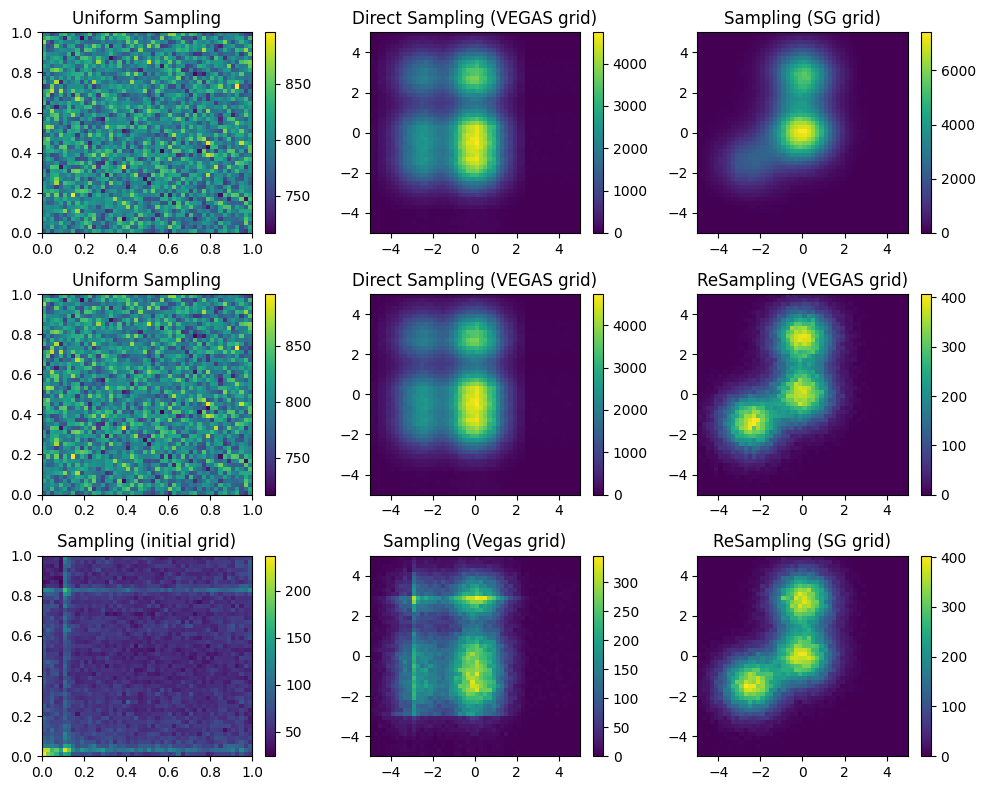

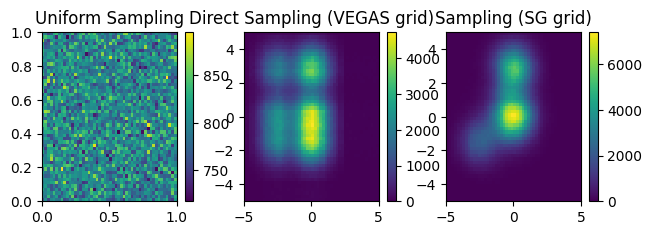

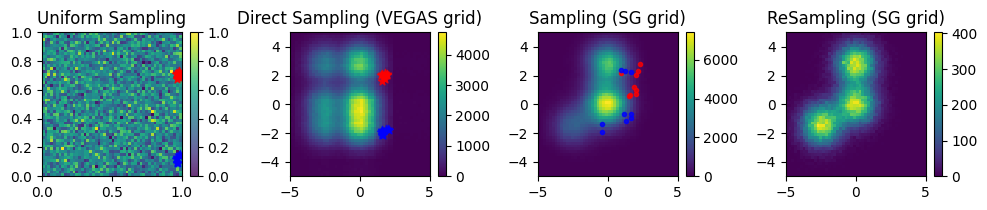

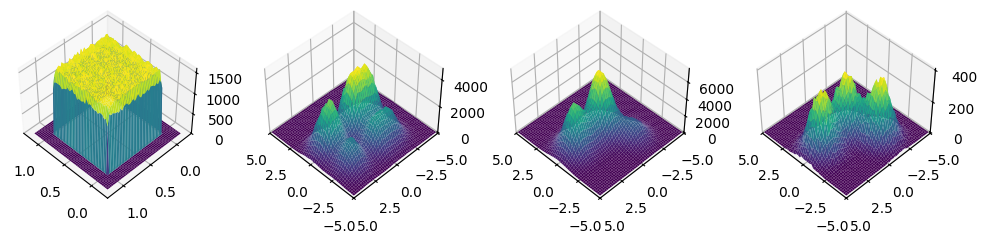

In [22]:
Loss_KL_ini = -torch.log(f_ini).mean()
Loss_KL_ini_std = torch.log(f_ini).std()
Loss_KL_ais = -torch.log(f_ais).mean()
Loss_KL_sg = -torch.log(f_SG).mean()
Loss_KL_sg_A = -torch.log(f_SG_A).mean()
print("SG-Uniform: Loss = ",  Loss_KL_ini)
print("SG-vg: Loss = ",  Loss_KL_ais)
print("SG-NF: LossA = ",  Loss_KL_sg_A)
print("SG-NF: Loss = ",  Loss_KL_sg)

with open("results/SG_cluster_result_" + str(Nd) + "d.dat", "w") as f:
    f.write(f"Monte Carlo Integral: "
            f"{I_ais} {err_ais} {I_SG_A} {err_SG_A} {I_SG} {err_SG}\n")
    f.write(f"SG-Uniform: Loss = {Loss_KL_ini}\n")
    f.write(f"SG-vg: Loss = {Loss_KL_ais}\n")
    f.write(f"SG-NF: LossA = {Loss_KL_sg_A}\n")
    f.write(f"SG-NF: Loss = {Loss_KL_sg}\n")


plot_SG_full(xini,x_ais_C,x_SG_nf,x0_ais_resample_B,x_resample_ini,x_resample_ais,x_SG)
